In [11]:
import torch
import torch.nn as nn  

import numpy as np
import pandas as pd

from scipy.io import loadmat,savemat
from torch.nn.parameter import Parameter
import matplotlib.pyplot as plt

import time

#Set default dtype to float32
torch.set_default_dtype(torch.float)

#PyTorch random number generator
torch.manual_seed(1234)

# Random number generators in other libraries
np.random.seed(1234)

# Device configuration
device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
# device2 = torch.device('cuda:1' if torch.cuda.is_available() else 'cpu')

print("Device 1: ",device)
# print("Device 2: ",device2)


Device 1:  cuda:0


In [2]:
sheet_name = '300rpm_2mms'


Omega = 300 #rpm
V = 2 #mm/s

lb_xyz = np.array([-50.0,-20.0,-3.0])
ub_xyz = np.array([50.0,20.0,0.0])

In [3]:
class Sequentialmodel(nn.Module):
    
    def __init__(self,layers,device,lb_xyz,ub_xyz,sheet_name):
        super().__init__() #call __init__ from parent class 
              
    
        self.activation = nn.Tanh()
        self.device = device
        self.loss_function = nn.MSELoss(reduction ='mean')
        
        self.layers = layers
        'Initialise neural network as a list using nn.Modulelist'  
        self.linears = nn.ModuleList([nn.Linear(layers[i], layers[i+1]) for i in range(len(layers)-1)])
        
        for i in range(len(layers)-1):
            nn.init.xavier_normal_(self.linears[i].weight.data, gain=1.0)
            # set biases to zero
            nn.init.zeros_(self.linears[i].bias.data) 
        
        self.beta = Parameter(torch.ones((64,len(layers)-2)))
        self.beta.requiresGrad = True

        self.ub = torch.from_numpy(ub_xyz).float().to(self.device)
        self.lb = torch.from_numpy(lb_xyz).float().to(self.device)

        Exp_data_filename = '/home/raghav/Documents/PINN_AFSD/Code_Final_Sept2024/AFSD_PINN/Experimental_Comparison_Only/ExperimentalData_and_Plots/Experimental_Data_Full.xlsx'
        data_exp = pd.read_excel(Exp_data_filename,sheet_name=sheet_name,header = None)
        data_exp= pd.DataFrame.to_numpy(data_exp).reshape((85,1),order='F')

        x_exp = np.linspace(-8,8,17)
        z_exp = np.linspace(0,-1,5)
        X_exp,Z_exp = np.meshgrid(x_exp,z_exp)

        X_exp = X_exp.reshape((-1,1),order = 'c')
        Z_exp = Z_exp.reshape((-1,1),order = 'c')

        xyz_exp = np.hstack((X_exp,20.0*np.ones((85,1)),Z_exp)) 

        self.T_exp = torch.from_numpy(data_exp).float().to(device)
        self.xyz_exp = torch.from_numpy(xyz_exp).float().to(device)

        mid_idx = range(17)
        self.T_exp = torch.from_numpy(data_exp[mid_idx,:]).float().to(device)
        self.xyz_exp = torch.from_numpy(xyz_exp[mid_idx,:]).float().to(device)

    
    
    'forward pass'
    def forward(self,x):
        if torch.is_tensor(x) != True:         
            x = torch.from_numpy(x)                

        #preprocessing input 
        x = 2.0*(x - self.lb)/(self.ub - self.lb) - 1.0 #feature scaling
        
        #convert to float
        a = x.float()
        
        for i in range(len(self.layers)-2):
            z = self.linears[i](a)
            a = self.activation(z) + self.beta[:,i]*z*self.activation(z)
            
        a = self.linears[-1](a) 
         
        return a
    
    def loss_exp_data(self):
        T_pred = self.forward(self.xyz_exp)

        loss_exp = self.loss_function(T_pred,self.T_exp)

        return loss_exp

In [4]:
def train_step():
    # def closure():
    optimizer.zero_grad()
    #model_PINN.zero_grad()
    loss = model_NN.loss_exp_data()
    loss.backward()

        # return loss

    optimizer.step()

In [5]:
def train_model(max_iter,rep,n_batches):
    print(rep)
    torch.manual_seed(rep*123)
    start_time = time.time()
    thresh_flag = 0

    loss_np = model_NN.loss_exp_data().cpu().detach().numpy()

    print(loss_np)
    print("Initial Train Loss",loss_np)

    
    for i in range(max_iter):
        train_step()
        # loss_np = PINN.loss(xyz_coll,xyz_1, xyz_2, xyz_3, xyz_4,xyz_top,xyz_bot,f_hat,N_hat).cpu().detach().numpy()
        # print(i,"Train Loss",train_loss[-1],"Test MSE",test_mse_loss[-1],"Test RE",test_re_loss[-1])
        loss_np = model_NN.loss_exp_data().cpu().detach().numpy() 
        print(i,"Train Loss",loss_np)
    
        # if(i>0 and i%25 ==0):
        #   pretrain(xyt_DBC,p_iters)
        if(loss_np<1):
            print("Loss Less than 1...")
            elapsed_time[rep] = time.time() - start_time
            break


    elapsed_time[rep] = time.time() - start_time
    print('Training time: %.2f' % (elapsed_time[rep]))

In [6]:
folder_main = '/home/smartlab/Documents/jupyterNB/raghav/Projects_git_summer2024/PINN_AFSD/Code_Final_Sept2024/AFSD_PINN/Experimental_Comparison_Only/ExperimentalData_and_Plots/'
# filename = 'Models_Trained_AFSD_Exp_2mms_z1mm_300rpm_2mms_8.pt'


label = 'meltpool'
max_reps = 1
max_iter = 10000
p_iters = 10

N_B = 1000
N_f = 10000
n_batches = 5

train_loss_full = []
test_mse_full = []
test_re_full = []
elapsed_time= np.zeros((max_reps,1))

time_threshold = np.empty((max_reps,1))
time_threshold[:] = np.nan
epoch_threshold = max_iter*np.ones((max_reps,1))

for reps in range(max_reps):

    train_loss = []
    test_mse_loss = []
    test_re_loss = []

    'Generate Training data'
    torch.manual_seed(reps*3)
     #Total number of collocation points


 
    layers = np.array([3,64,64,64,1]) #9 hidden layers
  
    model_NN = Sequentialmodel(layers,device,lb_xyz,ub_xyz,sheet_name)
    model_NN.to(device)

    'Neural Network Summary'
    print(model_NN)


    optimizer = torch.optim.Adam(model_NN.parameters(),lr=0.008, betas=(0.9, 0.999))

    start_time = time.time()
    train_model(max_iter,reps,n_batches)


    torch.save(model_NN.state_dict(),'./Models_Trained/NN_Exp_'+str(Omega)+'rpm_'+str(V)+ 'mms.pt')
    # train_loss_full.append(train_loss)
    # test_mse_full.append(test_mse_loss)
    # test_re_full.append(test_re_loss)


    print('Training time: %.2f' % (elapsed_time[reps]))

mdic = {"train_loss": train_loss_full,"test_mse_loss": test_mse_full, "test_re_loss": test_re_full, "Time": elapsed_time, "label": label, "Thresh Time": time_threshold,"Thresh epoch": epoch_threshold}
savemat(label+'.mat', mdic)

Sequentialmodel(
  (activation): Tanh()
  (loss_function): MSELoss()
  (linears): ModuleList(
    (0): Linear(in_features=3, out_features=64, bias=True)
    (1-2): 2 x Linear(in_features=64, out_features=64, bias=True)
    (3): Linear(in_features=64, out_features=1, bias=True)
  )
)
0
461869.03
Initial Train Loss 461869.03
0 Train Loss 458625.6
1 Train Loss 455323.34
2 Train Loss 451563.62
3 Train Loss 447066.3
4 Train Loss 441393.1
5 Train Loss 434238.84
6 Train Loss 425439.12
7 Train Loss 414950.47
8 Train Loss 402347.12
9 Train Loss 387115.2
10 Train Loss 369307.66
11 Train Loss 348406.94
12 Train Loss 324177.47
13 Train Loss 296327.25
14 Train Loss 264838.47
15 Train Loss 229562.94
16 Train Loss 190772.64
17 Train Loss 149267.55
18 Train Loss 106576.86
19 Train Loss 65609.695
20 Train Loss 30312.541
21 Train Loss 6495.041
22 Train Loss 1246.045
23 Train Loss 17776.434
24 Train Loss 43057.79
25 Train Loss 53837.72
26 Train Loss 43491.242
27 Train Loss 22062.412
28 Train Loss 4800.76

/tmp/ipykernel_165366/1644132557.py:29: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  print('Training time: %.2f' % (elapsed_time[rep]))
/tmp/ipykernel_165366/2301883931.py:56: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  print('Training time: %.2f' % (elapsed_time[reps]))


In [24]:
Exp_data_filename = '/home/raghav/Documents/PINN_AFSD/Code_Final_Sept2024/AFSD_PINN/Experimental_Comparison_Only/ExperimentalData_and_Plots/Experimental_Data_Full.xlsx'
data_exp = pd.read_excel(Exp_data_filename,sheet_name=sheet_name,header = None)
data_exp= pd.DataFrame.to_numpy(data_exp)

In [25]:
[x_min,y_min,z_min] = lb_xyz
[x_max,y_max,z_max] = ub_xyz

x_min = -8.0
x_max = 8.0

z_min = -1.0
z_max = 0.0

x = np.linspace(x_min,x_max,40).reshape(-1,1)
# y = np.linspace(y_min,y_max,200).reshape(-1,1)
y = 20.0
z = np.linspace(z_min,z_max,5).reshape(-1,1)
# z = -0.4
X,Y,Z = np.meshgrid(x,y,z)

X = X.flatten('F').reshape(-1,1)
Y = Y.flatten('F').reshape(-1,1)
Z = Z.flatten('F').reshape(-1,1)

xyz = np.hstack((X,Y,Z))


xyz_test_tensor = torch.from_numpy(xyz).float().to(device)

    # uvwp = model_PINN.PINN_uvw.forward(xyz_test_tensor).cpu().detach().numpy()
T_NN = model_NN.forward(xyz_test_tensor.to(device)).cpu().detach().numpy()
T_NN = np.flip(T_NN.reshape(5,40),axis = 0)

x_real = np.linspace(x_min,x_max,17).reshape(-1,1)

<>:22: SyntaxWarning: invalid escape sequence '\O'
<>:22: SyntaxWarning: invalid escape sequence '\O'
/tmp/ipykernel_165366/475963831.py:22: SyntaxWarning: invalid escape sequence '\O'
  ax.set_title('$\Omega$ = '+str(Omega)+'rpm, $V$ = ' + str(V)+'mm/s',fontsize = 16,math_fontfamily = 'cm')


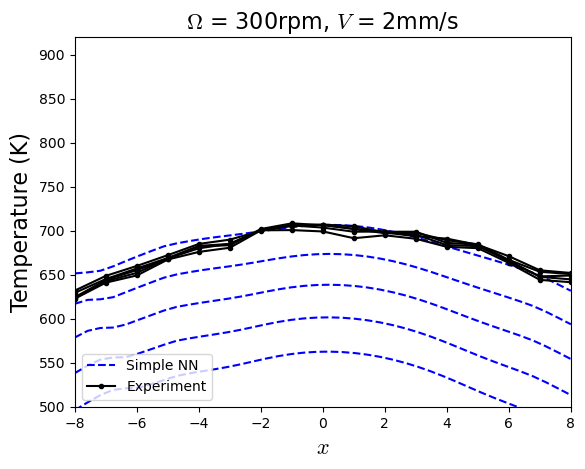

In [29]:
fig,ax = plt.subplots()

ax.plot(x,np.flip(T_NN[0,:]),'b--',label='Simple NN')
ax.plot(x,np.flip(T_NN[1,:]),'b--')
ax.plot(x,np.flip(T_NN[2,:]),'b--')
ax.plot(x,np.flip(T_NN[3,:]),'b--')
ax.plot(x,np.flip(T_NN[4,:]),'b--')


ax.plot(x_real,data_exp[:,0],'k.-',label = 'Experiment')
ax.plot(x_real,data_exp[:,1],'k.-')
ax.plot(x_real,data_exp[:,2],'k.-')
ax.plot(x_real,data_exp[:,3],'k.-')
ax.plot(x_real,data_exp[:,4],'k.-')


ax.legend(loc = 3)
ax.set_xlim([-8,8])
ax.set_xlabel('$x$',math_fontfamily = 'cm',fontsize = 16)
ax.set_ylabel('Temperature (K)',fontsize = 16)

ax.set_title('$\Omega$ = '+str(Omega)+'rpm, $V$ = ' + str(V)+'mm/s',fontsize = 16,math_fontfamily = 'cm')

ax.set_ylim([500,920])

fig.savefig('NN_Review.pdf',format='pdf',bbox_inches = 'tight')